# Домашнее задание: архитектура систем текстовой классификации

Добро пожаловать на бизнес-кейс по текстовой классификации!

В рамках данного домашнего задания вам предстоит пройти по всем этапам решения кейса, которые обычно затрагиваются при решении реальных продуктовых задач, а также кейсов на секциях по ML System Design.

Часть заданий требует текстового ответа в свободной форме, часть заданий - написания кода, обучения и инференса моделей и тп. В большинстве разделов нет сугубо правильных ответов или единственно верной реализации, однако есть хорошие практики и возможность выбрать из нескольких вариантов оптимальный. Поэтому в рамках задания местами надо будет делать выбор, от которого будет зависеть качество вашего потенциального продакшн-решения, возможности его поддержки и масштабирования.

Детали реализации вы можете выбирать любые, которые вам больше нравятся или кажется более удобными, в том числе по принципу "работает быстрее аналогов без существенной потери в качестве". Однако важное требование - **соблюдать структуру разделов в данном ноутбуке** -- это поможет решить задачу правильно, а также упростить проверку и написание фидбека по решению.

Представьте, что к вам пришел бизнес и попросил сделать супер-крутую систему по категоризации новостей. Как обычно бывает, единственное, что у вас есть - это формулировка задачи от продакт-менеджера; всё остальное он ожидает от вас.

Приятного кодинга!

## 1. Формулировка бизнес-задачи

**Контекст (от лица бизнеса):**  
Мы хотим автоматически распределять публикации нашего новостного портала по трем главным темам — политика, экономика, культура — чтобы:

- Улучшить таргетинг рекламных блоков.  
- Персонализировать ленту для пользователей.  
- Снизить ручные затраты редакторов.

**Чёткое описание задачи:**
> «Для каждой новости (заголовок + текст) автоматически определить, относится ли она к разделам `политика`, `экономика`, `культура`. Возможна множественная классификация (одна новость может быть сразу в нескольких разделах).»


## 2. Бизнес-метрики - 1 балл

Предложите бизнес-метрики, которые может хотеть оптимизировать бизнес в соответствии с формулировкой задачи. Предложите хотя три метрики, и постарайтесь их оцифровать, чтобы результаты были измеримы (насколько процентов что-то должно увеличиться?). Воспринимайте это как "прицелочные" цифры, к которым можно реалистично стремиться (реальные цифры на старте часто непонятно, но измеримые цели помогают четче формировать ожидания и текущее положение относительно них; в дальнейшем эти цифры можно корректировать на реальность).

In [1]:
# ваш ответ тут
# ---- Ваш код здесь ----
print("""
Хорошими метриками будет 
1. конверсия клика по рекламному блоку (количество кликов по рекламе / количество людей которые были на странице новости).  
Думаю, что можно измерить такое в рамках разных категорий и усреднить в рамках каждой категории. 
Посмотреть какой сейчас, а также после внедрения "нашей модели"
Это хорошая метрика, потому что конверсия клика в рекламу отражает интерес пользователя. 
Ну то есть если он попал в нужную категорию, то, наверное, он и по рекламе более охотно тыкнет. 
Также отражает прибыль бизнеса.
2. Время пользователя на сайте. Либо еще какие-то метрики, которые будут отражать вовлеченность. 
Например, возвращаемость или количество прочитанных новостей. Хорошие метрики, потому что отражают вовлеченность пользователя.
3. Количество статей, который были правильно соотнесены к разделам, относительно всех остальных статей. Ну то есть accuracy. Вроде бы напрямую отражает насколько снизились затраты редакторов. 
Можно еще посчитать сколько в час/день они могут относить к разделам, таким образом получить сколько часов/дней сэкономили редакторы. 
Соответственно мы сможем понять сколько мы сэкономили деняг и времени.
""")
# ---- Конец кода ----


Хорошими метриками будет 
1. конверсия клика по рекламному блоку (количество кликов по рекламе / количество людей которые были на странице новости).  
Думаю, что можно измерить такое в рамках разных категорий и усреднить в рамках каждой категории. 
Посмотреть какой сейчас, а также после внедрения "нашей модели"
Это хорошая метрика, потому что конверсия клика в рекламу отражает интерес пользователя. 
Ну то есть если он попал в нужную категорию, то, наверное, он и по рекламе более охотно тыкнет. 
Также отражает прибыль бизнеса.
2. Время пользователя на сайте. Либо еще какие-то метрики, которые будут отражать вовлеченность. 
Например, возвращаемость или количество прочитанных новостей. Хорошие метрики, потому что отражают вовлеченность пользователя.
3. Количество статей, который были правильно соотнесены к разделам, относительно всех остальных статей. Ну то есть accuracy. Вроде бы напрямую отражает насколько снизились затраты редакторов. 
Можно еще посчитать сколько в час/день они могут 

## 3. Сведение к ML-задаче - 2 балла

Сведите бизнес-задачу к задаче машинного обучения, опишите входные данные и метки:

- **Тип задачи**:
- **Объект**:
- **Метки**:


In [2]:
# ваш ответ тут
# ---- Ваш код здесь ----
print("""
- **Тип задачи**: multilabel classification
- **Объект**: Новость (заголовок + текст)
- **Метки**: [политика, экономика, культура]
""")
# ---- Конец кода ----


- **Тип задачи**: multilabel classification
- **Объект**: Новость (заголовок + текст)
- **Метки**: [политика, экономика, культура]



## 4. ML-метрики - 2 балла

Сформулируйте какие метрики вашей модели машинного обучения вы будете отслеживать в соответствии с ML-задачей, к которой вы свели бизнес-задачу. Укажите оффлайн метрики и предложите онлайн-метрики, которые вы в теории могли бы замерять в рамках A/B и в проде.

In [54]:
# ваш ответ тут
# ---- Ваш код здесь ----
print("""
- Оффлайн
  - Per-label Precision, Recall, F1
  - Micro / Macro average F1
  - Accuracy (что все классы в новости верны)
- Онлайн
  - Среднее время пользователей на сайте
  - Среднее количество прочитанных новостей по пользователям
  - Среднее CTR по рекламе 
""")
# ---- Конец кода ----


- Оффлайн
  - Per-label Precision, Recall, F1
  - Micro / Macro average F1
  - Accuracy
- Онлайн
  - Среднее время пользователей на сайте
  - Среднее количество прочитанных новостей по пользователям
  - Среднее CTR по рекламе 



## 5. Данные и разметка - 8 баллов

В данном пункте нам будет необходимо сделать магию -- за 0 рублей и две чашки кофе получить неплохую разметку, на которой можно будет обучаться.

Тк у вашего новостного агенства пока еще нет ни новостей, ни логов для них, ваши коллеги уже собрали по разным новостным сайтам логи с заголовком и текстом новости (а также источником и датой на всякий) в файле crawled_data.tsv. Необходимо считать и обработать данные из этого файла, в идеале с помощью pandas DataFrame.

Как мы обсуждали на лекции, по-хорошему, работа с данными должна идти немного в другой последовательности, нежели будем делать мы: обычно сначала мы собираемся с бизнесом, пишем и оттачиваем инструкцию и собираем golden dataset. В рамках данной задачи будем считать, что у нас такой возможности нет, и нам будет ок получить MVP-разметку с помощью LLM -- это быстро, задача не самая сложная для LLM, плюс в целом качество такой разметки можно контролировать и улучшать при необходимости.

В этом пункте необходимо выбрать какую-нибудь open-source LLM, написать к ней промпт (можно простой и небольшой) и разметить какое-то количество данных, которое вам может показаться достаточным для обучения в этой задаче. Можете начать с небольшого количества, и постепенно его увеличивать, отслеживая, как при этом меняется качество.

LLM для разметки можно выбирать любую, но вам предстоит соблюсти баланс между качеством и возможостью инферить ее на GPU. В качестве неплохой модели для разметки русскоязычных текстов можете использовать https://huggingface.co/IlyaGusev/saiga_yandexgpt_8b: ее несложно проинферить кодом и она уже оптимизирована и влезает в GPU T4 на колабе. Можно выбирать и любую другую модель, но, возможно, вам придется повозиться с ее инференсом.

Далее вам необходимо будет реализовать функцию для инференса этой LLM с учетом промпта и входа, и циклом получить разметку по всем трем категориям из задачи. Будьте максимально аккуратны с используемой памятью, иначе в середине цикла инференс может падать с ошибкой Cuda Out of Memory. Для избежания этого можете после каждого инференса делать следующее:
- torch.cuda.empty_cache()
- перетаскивать **всё** вычисленное с GPU на CPU
- удалять все уже использованное переменные через del
- ограничивать размер входа и выхода
- если падают единичные примеры -- выкидывать их

В конечном счете в вашем датафрейме должны оказаться следующие колонки:

`['source', 'title', 'text', 'publication_date', 'politics', 'economy',
       'culture', 'generation']`,
где `generation` -- ответ генеративной модели в сыром виде; 'politics', 'economy', 'culture' -- наличие категории со значением 1/0, полученные из generation.

Отлаживайте разметку на небольшом семпле данных. Как только разметите нужное вам количество примеров, не забудьте сохранить их в отдельный файл, чтобы не потерять разметку.

Для искушенных - можно пользоваться vLLM для ускорения инференса или together https://api.together.xyz/signin?redirectUrl=%2F (они дают один доллар бесплатно)

In [58]:

# ---- Ваш код здесь ----
print("""
Считываем данные
""")
import pandas as pd

DATA_PATH = '../../files/crawleddata.tsv'
data = pd.read_csv(DATA_PATH, sep='\t', names=['source', 'title', 'text', 'publication_date']).dropna()


Считываем данные



In [59]:
data.shape[0]

20780

In [60]:
data

,source,title,text,publication_date
0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00
1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00
2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00
3,lenta.ru,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,2020-08-30T00:04:00+03:00
4,lenta.ru,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,2020-08-31T18:27:00+03:00
...,...,...,...,...
21064,ria.ru,Самолеты НАТО стали чаще летать у границ Росси...,"МОСКВА, 23 дек - РИА Новости. Интенсивность п...",00:39 23.12.2019 (обновлено: 18:27 03.03.2020)
21065,ria.ru,Сюткин оценил шутку Шнурова над обидевшим Гага...,"МОСКВА, 23 дек — РИА Новости. Певец Валерий ...",00:50 23.12.2019 (обновлено: 18:27 03.03.2020)
21066,ria.ru,Владимир Путин откроет железнодорожное движени...,"МОСКВА, 23 дек — РИА Новости. Владимир Путин...",01:07 23.12.2019 (обновлено: 16:19 11.01.2020)
21067,ria.ru,Концертный директор прокомментировал скандал Б...,"МОСКВА, 23 дек — РИА Новости. Концертный дире...",01:49 23.12.2019 (обновлено: 18:27 03.03.2020)


In [10]:
# ---- Конец кода ----

In [2]:
! python --version

Python 3.11.15


In [3]:
import transformers
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, BitsAndBytesConfig
import json
import re

In [5]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.5.1+cu121
12.1
True
CUDA available: True
Device count: 1
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


In [64]:
# ---- Ваш код здесь ----
print("""
    Загружаем выбранную LLM
    В некоторых случаях может понадобиться !pip install -U accelerate bitsandbytes transformers
""")


    Загружаем выбранную LLM
    В некоторых случаях может понадобиться !pip install -U accelerate bitsandbytes transformers



In [ ]:
MODEL_NAME = "IlyaGusev/saiga_yandexgpt_8b"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True
)

In [9]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model.eval()

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(129024, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
      )
    )
    (

In [204]:
generation_config = GenerationConfig.from_pretrained(MODEL_NAME)
print(generation_config)

GenerationConfig {
  "bos_token_id": 1,
  "do_sample": true,
  "eos_token_id": 128009,
  "max_length": 1024000,
  "max_new_tokens": 2048,
  "pad_token_id": 0,
  "repetition_penalty": 1.1,
  "temperature": 0.6,
  "top_p": 0.95
}



In [ ]:
generation_config.do_sample = False
generation_config.max_new_tokens = 256
generation_config.use_cache = True
generation_config.max_length = None

In [213]:
generation_config

GenerationConfig {
  "bos_token_id": 1,
  "do_sample": false,
  "eos_token_id": 128009,
  "max_new_tokens": 256,
  "pad_token_id": 0,
  "repetition_penalty": 1.1,
  "temperature": 0.6,
  "top_p": 0.95,
  "use_cache": true
}

In [209]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [ ]:

# ---- Конец кода ----

In [136]:
# Промпт


# ---- Ваш код здесь ----
def prompt_template(text: str):
    return f"""Ты — эксперт по классификации новостей.
    Твоя задача: определить, к каким категориям относится новость.
    
    Категории:
    - politics — политика, выборы, международные отношения, законы, власть, государство
    - economy — экономика, бизнес, финансы, рынок, банки, компании, нефть, инфляция
    - culture — культура, искусство, кино, музыка, литература, шоу-бизнес, спорт
    
    Важно:
    - Можно выбрать несколько категорий одновременно
    - Можно выбрать ни одной (если новость не относится)
    - Отвечай ТОЛЬКО в заданном формате
    
    Формат ответа:
    {{"generation": "your short reasoning",
        "politics": 0 или 1,
        "economy": 0 или 1,
        "culture": 0 или 1
    }}
    
    
    Новость:
    {text}
"""
# ---- Конец кода ----

In [139]:
len_prompt = len(prompt_template(''))

In [140]:
len_prompt

740

In [214]:
 # Функция разметки

# @torch.no_grad() # можно включить декоратор
def annotate(text: str, max_length:int=2560) -> dict:
    """
    Формат markup следующий
        markup = {
        'politics': 0/1,
        'economy': 0/1,
        'culture': 0/1,
        'corrupted': 0/1, # сломалось ли что-то при получении разметки
        'generation': llm_generation # чтобы можно было раздебажить закоррапченные разметки
    }
    """
    try:
        # вставляем текст в шаблон, обрезаем на всякий чтоб не падало по памяти лишний раз
        # prompt_input = prompt_template.format(text=text[:1500]) # обрезаем слишком длинные новости


        # может понадобиться, может нет -- зависит от выбранной вами модели
        # prompt = tokenizer.apply_chat_template([{
        #     "role": "user",
        #     "content": prompt_input
        # }], tokenize=False, add_generation_prompt=True)

        # markup = {}
        # with torch.no_grad():
        #     # inference tokenizer, model ...

        #     del ... # удаляем ненужные переменные
        #     torch.cuda.empty_cache()

        #     return markup

        # ---- Ваш код здесь ----
        with torch.inference_mode():
            prompt_input = prompt_template(text[:1500]) # обрезаем слишком длинные новости
    
            prompt = tokenizer.apply_chat_template([{
                "role": "user",
                "content": prompt_input
            }], tokenize=False, add_generation_prompt=True)
            
            data = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
            # data = {k: v.to(model.device) for k, v in data.items()}
            # data.pop("token_type_ids", None)
            data.to(model.device)
            output_ids = model.generate(**data, generation_config=generation_config)[0]
            output_ids = output_ids[len(data["input_ids"][0]):]
            output = tokenizer.decode(output_ids, skip_special_tokens=True).strip()
            
            del data, output_ids, prompt, prompt_input
    
            gc.collect()
            
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    
        try: 
            start = output.find('{')
            end = output.find('}') + 1
            markup = json.loads(output[start:end])
            markup['corrupted'] = 0
        except:
            markup = {
                'politics': 0, 'economy': 0, 'culture': 0,
                'corrupted': 1,
                'generation': output
            }

        return markup
    # ---- Конец кода ----

    except torch.cuda.OutOfMemoryError:
        print("CUDA OOM. Освобождаем память...")
        torch.cuda.empty_cache()
        return {
            'politics': 0, 'economy': 0, 'culture': 0,
            'corrupted': 1,
            'generation': 'OOM_ERROR'
        }

In [216]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

In [170]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [217]:
output = annotate(data.loc[0]['title'] + '. ' + data.loc[0]['text'])
output

{'generation': 'История трудового подвига Алексея Стаханова в контексте политики СССР 1930-х годов и его влияния на культуру того времени.',
 'politics': 1,
 'economy': 1,
 'culture': 1,
 'corrupted': 0}

In [146]:
data.columns

Index(['source', 'title', 'text', 'publication_date'], dtype='str')

In [171]:
from tqdm import tqdm

In [ ]:
# ---- Ваш код здесь ----
print("""
    прокачиваем в цикле выбранную LLM для разметки данных через функцию annotate, добавляем разметку в исходный датасет и сохраняем в файл
""")

In [220]:
new_rows = list()
save_n = 25
i = 0
part = 0
n_max = 5000

for _, row in tqdm(data[:n_max].iterrows(), total=data[:n_max].shape[0]):
    output = annotate(row['title'] + '. ' + row['text'])
    new_row = {'source': row['source'], 
               'title': row['title'],
               'text' : row['text'], 
               'publication_date' : row['publication_date']}

    new_row.update(output)
    new_rows.append(new_row)
    i += 1
    
    if i == save_n:
        pd.DataFrame(new_rows).to_csv(f'../../files/razmetka/razmetka_part_{part}.csv', index=None)
        part += 1
        i = 0
        del new_rows

        gc.collect()
        new_rows = list()



pd.DataFrame(new_rows).to_csv(f'../../files/razmetka/razmetka_part_{part}.csv', index=None)

100%|████████████████████████████████████████████████████████████████████████████| 5000/5000 [9:55:19<00:00,  7.14s/it]


In [ ]:

# ---- Конец кода ----



### Разделение данных на трейн и тест - 2 балла

Проведите минимальный EDA и реализуйте разделение на трейн и тест в соответствии с природой данных и постановкой задачи. В результате получите два датафрема: train_df и test_df.

In [40]:
# ---- Ваш код здесь ----
print("EDA и разделение на трейн-тест")

import pandas as pd
import glob
import os
import gc

EDA и разделение на трейн-тест


In [25]:
path = '../../files/razmetka/'

In [46]:
files = glob.glob(os.path.join(path, "razmetka_part_*.csv"))

In [47]:
files

['../../files/razmetka\\razmetka_part_0.csv',
 '../../files/razmetka\\razmetka_part_1.csv',
 '../../files/razmetka\\razmetka_part_10.csv',
 '../../files/razmetka\\razmetka_part_100.csv',
 '../../files/razmetka\\razmetka_part_101.csv',
 '../../files/razmetka\\razmetka_part_102.csv',
 '../../files/razmetka\\razmetka_part_103.csv',
 '../../files/razmetka\\razmetka_part_104.csv',
 '../../files/razmetka\\razmetka_part_105.csv',
 '../../files/razmetka\\razmetka_part_106.csv',
 '../../files/razmetka\\razmetka_part_107.csv',
 '../../files/razmetka\\razmetka_part_108.csv',
 '../../files/razmetka\\razmetka_part_109.csv',
 '../../files/razmetka\\razmetka_part_11.csv',
 '../../files/razmetka\\razmetka_part_110.csv',
 '../../files/razmetka\\razmetka_part_111.csv',
 '../../files/razmetka\\razmetka_part_112.csv',
 '../../files/razmetka\\razmetka_part_113.csv',
 '../../files/razmetka\\razmetka_part_114.csv',
 '../../files/razmetka\\razmetka_part_115.csv',
 '../../files/razmetka\\razmetka_part_116.csv'

In [41]:
for f in files:
    try:
        t = pd.read_csv(f)
        del t
        gc.collect()
    except:
        print(f)

../../files/razmetka\razmetka_part_200.csv


In [48]:
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

In [49]:
df

,source,title,text,publication_date,generation,politics,economy,culture,corrupted,science,...,traffic,security,social,medicine,science_technology,space,social_issues,natural_disasters,education,animal_welfare
0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00,История трудового подвига Алексея Стаханова в ...,1,1,1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00,Спортсменка Алина Загитова решила расширить св...,0,0,1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00,"Статья посвящена здоровью и питанию, но содерж...",0,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lenta.ru,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,2020-08-30T00:04:00+03:00,Влияние телевизионного шоу '16 and Pregnant' н...,0,0,1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,lenta.ru,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,2020-08-31T18:27:00+03:00,Эта новость касается личной жизни известного а...,0,0,1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,lenta.ru,Выступавший в НХЛ игрок назвал плюсы жизни в К...,Российский хоккеист московского ЦСКА Никола...,2020-04-17T23:46:00+03:00,Сравнение жизни в разных странах через призму ...,0,0,1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4996,lenta.ru,Песков объяснил причину переноса сроков подачи...,Пресс-секретарь президента России Дмитрий Пес...,2020-04-17T23:23:00+03:00,Перенос сроков подачи деклараций о доходах чин...,1,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,lenta.ru,Лукашенко раскритиковал российские тесты на ко...,Президент Белоруссии Александр Лукашенко рас...,2020-04-17T22:51:00+03:00,Критика российских тестов и советы населению о...,1,1,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4998,lenta.ru,В Петербурге медики массово заразились коронав...,В Боткинскую больницу в Санкт-Петербурге госпи...,2020-04-17T22:17:00+03:00,Эта новость касается распространения COVID-19 ...,1,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
df[['source', 'title', 'text', 'publication_date', 'generation', 'politics',
       'economy', 'culture', 'corrupted']].to_csv('../../files/razmetka_all.csv')

In [62]:
data = pd.read_csv('../../files/razmetka_all.csv'))
data

,source,title,text,publication_date,generation,politics,economy,culture,corrupted
0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00,История трудового подвига Алексея Стаханова в ...,1,1,1,0
1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00,Спортсменка Алина Загитова решила расширить св...,0,0,1,0
2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00,"Статья посвящена здоровью и питанию, но содерж...",0,0,0,0
3,lenta.ru,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,2020-08-30T00:04:00+03:00,Влияние телевизионного шоу '16 and Pregnant' н...,0,0,1,0
4,lenta.ru,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,2020-08-31T18:27:00+03:00,Эта новость касается личной жизни известного а...,0,0,1,0
...,...,...,...,...,...,...,...,...,...
4995,lenta.ru,Выступавший в НХЛ игрок назвал плюсы жизни в К...,Российский хоккеист московского ЦСКА Никола...,2020-04-17T23:46:00+03:00,Сравнение жизни в разных странах через призму ...,0,0,1,0
4996,lenta.ru,Песков объяснил причину переноса сроков подачи...,Пресс-секретарь президента России Дмитрий Пес...,2020-04-17T23:23:00+03:00,Перенос сроков подачи деклараций о доходах чин...,1,0,0,0
4997,lenta.ru,Лукашенко раскритиковал российские тесты на ко...,Президент Белоруссии Александр Лукашенко рас...,2020-04-17T22:51:00+03:00,Критика российских тестов и советы населению о...,1,1,0,0
4998,lenta.ru,В Петербурге медики массово заразились коронав...,В Боткинскую больницу в Санкт-Петербурге госпи...,2020-04-17T22:17:00+03:00,Эта новость касается распространения COVID-19 ...,1,0,0,0


In [63]:
data.politics.isna().sum()

np.int64(0)

In [64]:
data.economy.isna().sum()

np.int64(0)

In [65]:
data.culture.isna().sum()

np.int64(0)

In [66]:
data['corrupted'].value_counts()

corrupted
0    5000
Name: count, dtype: int64

In [74]:
data.groupby(['politics', 'economy', 'culture'])['source'].count().to_frame() / data.shape[0] * 100

source
politics economy culture        
0        0       0          8.28
                 1         17.98
         1       0          4.00
                 1          1.82
1        0       0         38.34
                 1          8.94
         1       0         18.90
                 1          1.74

In [76]:
for c in ['politics', 'economy', 'culture']:
    display(data[c].value_counts(normalize=True))

politics
1    0.6792
0    0.3208
Name: proportion, dtype: float64

economy
0    0.7354
1    0.2646
Name: proportion, dtype: float64

culture
0    0.6952
1    0.3048
Name: proportion, dtype: float64

In [97]:
data.groupby('source')['title'].count()

source
lenta.ru     4487
meduza.io     513
Name: title, dtype: int64

In [80]:
from sklearn.model_selection import train_test_split

In [89]:
train_df, test_df = train_test_split(data, test_size=0.15)

In [90]:
train_df.shape[0] / data.shape[0]

0.85

In [91]:
test_df.shape[0] / data.shape[0]

0.15

In [93]:
train_df, val_df = train_test_split(train_df, test_size=0.10)

In [94]:
(train_df.shape[0] / data.shape[0],
 val_df.shape[0] / data.shape[0],
test_df.shape[0] / data.shape[0])

(0.765, 0.085, 0.15)

In [98]:
train_df.groupby(['politics', 'economy', 'culture'])['source'].count().to_frame() / data.shape[0] * 100

source
politics economy culture        
0        0       0          6.40
                 1         13.58
         1       0          2.98
                 1          1.40
1        0       0         29.44
                 1          6.72
         1       0         14.66
                 1          1.32

In [99]:
test_df.groupby(['politics', 'economy', 'culture'])['source'].count().to_frame() / data.shape[0] * 100

source
politics economy culture        
0        0       0          1.14
                 1          2.84
         1       0          0.64
                 1          0.30
1        0       0          5.74
                 1          1.38
         1       0          2.72
                 1          0.24

In [100]:
for c in ['politics', 'economy', 'culture']:
    display(train_df[c].value_counts(normalize=True))

politics
1    0.681569
0    0.318431
Name: proportion, dtype: float64

economy
0    0.733856
1    0.266144
Name: proportion, dtype: float64

culture
0    0.699085
1    0.300915
Name: proportion, dtype: float64

In [101]:
for c in ['politics', 'economy', 'culture']:
    display(test_df[c].value_counts(normalize=True))

politics
1    0.672
0    0.328
Name: proportion, dtype: float64

economy
0    0.74
1    0.26
Name: proportion, dtype: float64

culture
0    0.682667
1    0.317333
Name: proportion, dtype: float64

In [95]:
train_df.columns

Index(['source', 'title', 'text', 'publication_date', 'generation', 'politics',
       'economy', 'culture', 'corrupted'],
      dtype='str')

In [ ]:

# ---- Конец кода ----

## 6. Архитектура и пайплайн - 5 баллов

Самое существенное в данном задании - правильно выбрать ML-архитектуру решения. Подумайте, с учетом постановки задачи и целей бизнеса, как стоит построить обучение и инференс вашей модели.

В любом случае вам понадобится какая-то предобученная модель. В случае, если вы остановитесь на BERT-подобной, можно выбрать любую подходящую под задачу отсюда: https://huggingface.co/models?pipeline_tag=feature-extraction&sort=trending. Вспомните, на что стоит ориентироваться при выборе эмбеддера.

Если хочется выбрать BERT полегче, можете посмотреть в сторону такой модели: https://huggingface.co/cointegrated/rubert-tiny2

В качестве ответа:
- опишите, как будет выглядеть пайплайн подготовки данных, обучения и инференса вашей классификации для всех категорий.
- опишите, почему вы выбрали именно такую архитектуру, какие у нее преимущества и какие недостатки.
- если используете предобученную модель, то напишите какую и как ее найти, а также почему вы выбрали именно ее.

In [102]:

# ---- Ваш код здесь ----
print("""Вот так будет выглядеть пайплайн: 
1. Предобученный эмбеддер (BERT-like encoder). ruBERT-tiny2. Потому что 
    1.1. русский язык 
    1.2. лёгкая модель 
    1.3. быстрый инференс 
    1.4. подходит для MVP
    1.5. в production можно масштабировать до более крупных моделей (ruBERT-large, XLM-R, LLM)
2. На вход текст. Объединение title + text (как делал в разметке). Токенизация.
3. Модель  — эмбеддер + бинарная голова на каждую категорию. 
3.1. Я выбрал такую архитектуру, потому что система должна быть расширяемой и легко будет добавить категории без перееобучения всей сети.
3.2. Я думаю, что при фиксированном числе классов можно было бы сделать одну multilabel голову, 
ведь отдельные головы хуже учитывают зависимости между классами
4. Обучение - loss: BCEWithLogitsLoss. 
4.1. fine-tuning предобученного encoder’а вместе с классификационными головам.
5. Inference: три вероятности класса. 
6. Далее я бы подобрал пороги по F1 для каждого класса (для этого мне нужна отдельная выборка - val_df)
""")


# ---- Конец кода ----

Вот так будет выглядеть пайплайн: 
1. Предобученный эмбеддер (BERT-like encoder). ruBERT-tiny2. Потому что 
    1.1. русский язык 
    1.2. лёгкая модель 
    1.3. быстрый инференс 
    1.4. подходит для MVP
    1.5. в production можно масштабировать до более крупных моделей (ruBERT-large, XLM-R, LLM)
2. На вход текст. Объединение title + text (как делал в разметке). Токенизация.
3. Модель  — эмбеддер + бинарная голова на каждую категорию. 
3.1. Я выбрал такую архитектуру, потому что система должна быть расширяемой и легко будет добавить категории без перееобучения всей сети.
3.2. Я думаю, что при фиксированном числе классов можно было бы сделать одну multilabel голову, 
ведь отдельные головы хуже учитывают зависимости между классами
4. Обучение - loss: BCEWithLogitsLoss. 
4.1. fine-tuning предобученного encoder’а вместе с классификационными головам.
5. Inference: три вероятности класса. 
6. Далее я бы подобрал пороги по F1 для каждого класса (для этого мне нужна отдельная выборка - va

## 7. Обучение модели - 10 баллов

Реализуйте архитектуру и пайплайн, описанный в предыдущем пункте. Реализуйте все классы и методы, необходимые для обработки данных, обучения и инференса.

Обучите модель предсказывать все указанные категории на полученных вами данных. Не забывайте считать train и val лоссы в процессе обучения. В выводе ячеек крайне желательно отобразить процесс обучения (tqdm или принты с лоссами каждую эпоху).

### Классы для обучения и подготовки данных

In [104]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import os
import joblib


# ---- Ваш код здесь ----
print("Пишем классы, обучаем")
# ---- Конец кода ----

Пишем классы, обучаем


In [105]:
class NewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.texts = (df["title"] + " " + df["text"]).tolist()
        self.labels = df[["politics", "economy", "culture"]].values.astype(float)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)

        return item

In [106]:
class MultiHeadClassifier(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.head_politics = nn.Linear(hidden_size, 1)
        self.head_economy = nn.Linear(hidden_size, 1)
        self.head_culture = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0]  # CLS токен

        p = self.head_politics(cls)
        e = self.head_economy(cls)
        c = self.head_culture(cls)

        logits = torch.cat([p, e, c], dim=1)

        return logits


In [134]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = NewsDataset(train_df, tokenizer)
val_dataset = NewsDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

model = MultiHeadClassifier(model_name).to(device)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [135]:
print(type(model))

<class '__main__.MultiHeadClassifier'>


In [136]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)

            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.sigmoid(logits)

            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return total_loss / len(loader), np.vstack(all_preds), np.vstack(all_labels)

In [137]:
print(type(model))

<class '__main__.MultiHeadClassifier'>


In [138]:
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}")

    train_loss = train_epoch(model, train_loader)
    val_loss, preds, labels = eval_epoch(model, val_loader)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")


Epoch 1


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 14.16it/s]


Train loss: 0.5095
Val loss: 0.3802

Epoch 2


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 18.22it/s]


Train loss: 0.3232
Val loss: 0.3054

Epoch 3


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 18.01it/s]

Train loss: 0.2621
Val loss: 0.2812


In [139]:
preds

array([[0.98983884, 0.05543438, 0.03502103],
       [0.8716714 , 0.04715056, 0.7308152 ],
       [0.40387955, 0.05658992, 0.9779603 ],
       ...,
       [0.7412613 , 0.9908048 , 0.02543474],
       [0.5995801 , 0.26898828, 0.02480423],
       [0.04044812, 0.13063695, 0.288105  ]],
      shape=(425, 3), dtype=float32)

In [143]:
from sklearn.metrics import roc_auc_score

In [141]:
y_true = val_df[["politics", "economy", "culture"]].values
y_score = preds

In [144]:
results = {}

for i, name in enumerate(["politics", "economy", "culture"]):
    results[name] = roc_auc_score(y_true[:, i], y_score[:, i])

pd.Series(results)

politics    0.946190
economy     0.916277
culture     0.939693
dtype: float64

In [146]:
from sklearn.metrics import f1_score

def find_best_thresholds(preds, labels):
    thresholds = []

    for i in range(labels.shape[1]):
        best_f1 = 0
        best_t = 0.5

        for t in np.linspace(0.1, 0.9, 17):
            pred_bin = (preds[:, i] > t).astype(int)
            f1 = f1_score(labels[:, i], pred_bin)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    return thresholds

In [147]:
thresholds = find_best_thresholds(y_score, y_true)

In [148]:
thresholds

[np.float64(0.55), np.float64(0.45000000000000007), np.float64(0.4)]

In [177]:
def get_scores(model, loader, device):
    model.eval()
    all_scores = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits)

            all_scores.append(probs.cpu().numpy())

    return np.vstack(all_scores)

In [149]:
def predict(model, loader, thresholds):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits)

            all_preds.append(probs.cpu().numpy())

    probs = np.vstack(all_preds)

    preds = (probs > thresholds).astype(int)

    return preds

In [150]:
test_dataset = NewsDataset(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [151]:
val_preds = predict(model, val_loader, thresholds)

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:01<00:00, 13.73it/s]


In [152]:
val_preds

array([[1, 0, 0],
       [1, 0, 1],
       [0, 0, 1],
       ...,
       [1, 1, 0],
       [1, 0, 0],
       [0, 0, 0]], shape=(425, 3))

In [155]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

In [163]:
y_true = val_df[["politics", "economy", "culture"]].values
y_pred = val_preds  

labels = ["politics", "economy", "culture"]

for i, name in enumerate(labels):
    precision = precision_score(y_true[:, i], y_pred[:, i])
    recall = recall_score(y_true[:, i], y_pred[:, i])
    f1 = f1_score(y_true[:, i], y_pred[:, i])

    print(f"{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")

politics:
  Precision: 0.8963
  Recall:    0.9404
  F1:        0.9178
economy:
  Precision: 0.8218
  Recall:    0.7545
  F1:        0.7867
culture:
  Precision: 0.7902
  Recall:    0.8370
  F1:        0.8129


In [164]:
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

Micro F1: 0.8648648648648649
Macro F1: 0.8391625724285857


In [165]:
strict_accuracy = accuracy_score(y_true, y_pred)

print("Strict (subset) accuracy:", strict_accuracy)

Strict (subset) accuracy: 0.7176470588235294


In [157]:
test_preds = predict(model, test_loader, thresholds)

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:01<00:00, 14.73it/s]


In [158]:
y_true = test_df[["politics", "economy", "culture"]].values
y_pred = test_preds  # уже после thresholding

labels = ["politics", "economy", "culture"]

for i, name in enumerate(labels):
    precision = precision_score(y_true[:, i], y_pred[:, i])
    recall = recall_score(y_true[:, i], y_pred[:, i])
    f1 = f1_score(y_true[:, i], y_pred[:, i])

    print(f"{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")

politics:
  Precision: 0.9248
  Recall:    0.9028
  F1:        0.9137
economy:
  Precision: 0.8024
  Recall:    0.6872
  F1:        0.7403
culture:
  Precision: 0.8069
  Recall:    0.8782
  F1:        0.8410


In [159]:
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

Micro F1: 0.8603773584905661
Macro F1: 0.8316774626175328


In [162]:
strict_accuracy = accuracy_score(y_true, y_pred)

print("Strict (subset) accuracy:", strict_accuracy)

Strict (subset) accuracy: 0.6973333333333334


## 8. Оценка и интерпретация - 5 баллов

Постройте и посчитайте следующие вещи на тесте для каждой категории:
- Графики: roc-кривую, распределение вероятностей для класса 1 и 0 (на одном графике), confusion matrix
- Метрики: precision, recall, f1 при оптимально подобранном пороге, roc auc

In [173]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

In [166]:
y_true = test_df[["politics", "economy", "culture"]].values
y_pred = test_preds  

labels = ["politics", "economy", "culture"]

for i, name in enumerate(labels):
    precision = precision_score(y_true[:, i], y_pred[:, i])
    recall = recall_score(y_true[:, i], y_pred[:, i])
    f1 = f1_score(y_true[:, i], y_pred[:, i])

    print(f"{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")

politics:
  Precision: 0.9248
  Recall:    0.9028
  F1:        0.9137
economy:
  Precision: 0.8024
  Recall:    0.6872
  F1:        0.7403
culture:
  Precision: 0.8069
  Recall:    0.8782
  F1:        0.8410


In [167]:
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

Micro F1: 0.8603773584905661
Macro F1: 0.8316774626175328


Accuracy, что новость целиком совпала

In [168]:
strict_accuracy = accuracy_score(y_true, y_pred)

print("Strict (subset) accuracy:", strict_accuracy)

Strict (subset) accuracy: 0.6973333333333334


In [175]:
y_true

array([[1, 0, 0],
       [0, 0, 0],
       [1, 0, 0],
       ...,
       [0, 0, 1],
       [1, 1, 0],
       [1, 0, 1]], shape=(750, 3))

In [178]:
y_score = get_scores(model, test_loader, device)

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:01<00:00, 13.79it/s]


In [179]:
y_score

array([[0.72909606, 0.00757732, 0.82764244],
       [0.15693088, 0.03066182, 0.13741425],
       [0.95461816, 0.07685107, 0.01042594],
       ...,
       [0.0579317 , 0.03121831, 0.9782016 ],
       [0.7918283 , 0.11584926, 0.01870488],
       [0.16854362, 0.09342623, 0.5367368 ]],
      shape=(750, 3), dtype=float32)

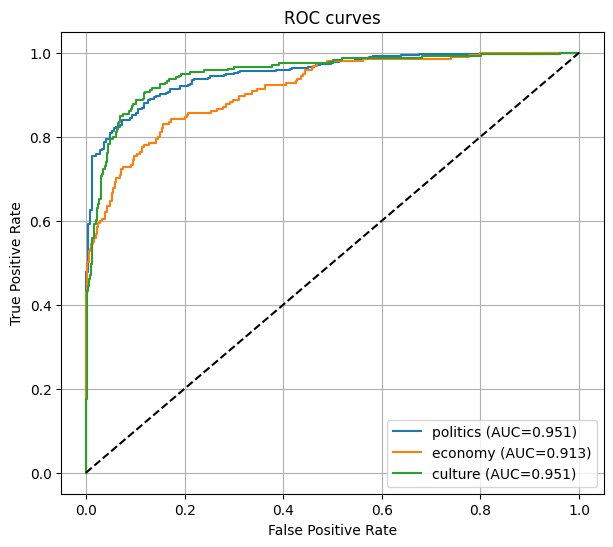

In [180]:
labels = ["politics", "economy", "culture"]

plt.figure(figsize=(7, 6))

for i, name in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.grid()
plt.show()

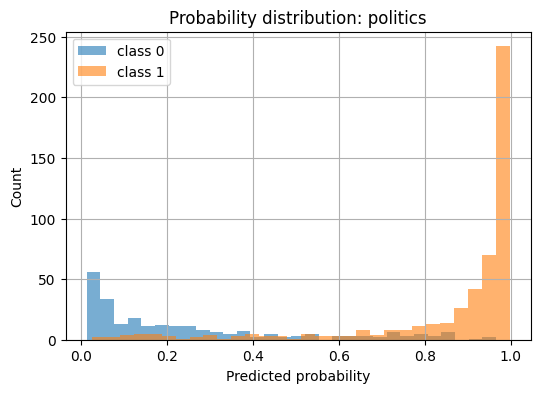

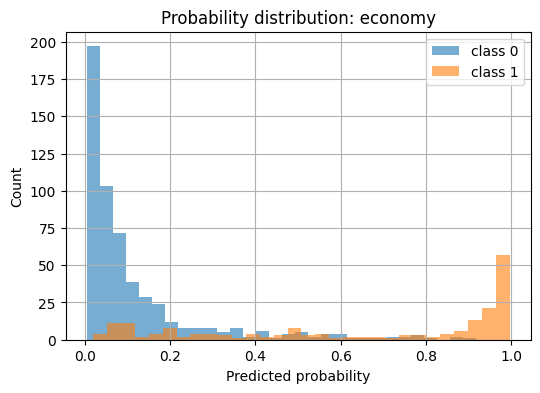

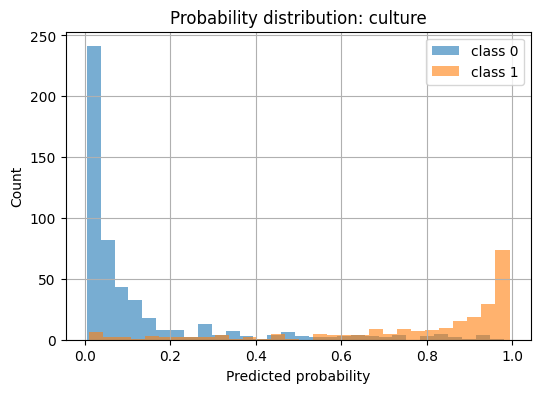

In [181]:
labels = ["politics", "economy", "culture"]

for i, name in enumerate(labels):
    plt.figure(figsize=(6, 4))

    probs_pos = y_score[y_true[:, i] == 1, i]
    probs_neg = y_score[y_true[:, i] == 0, i]

    plt.hist(probs_neg, bins=30, alpha=0.6, label="class 0")
    plt.hist(probs_pos, bins=30, alpha=0.6, label="class 1")

    plt.title(f"Probability distribution: {name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.legend()
    plt.grid()
    plt.show()

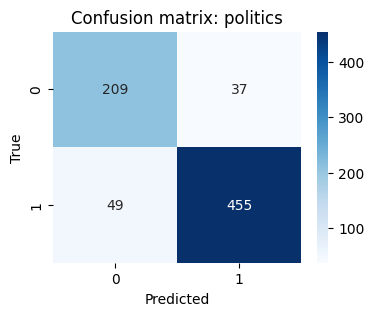

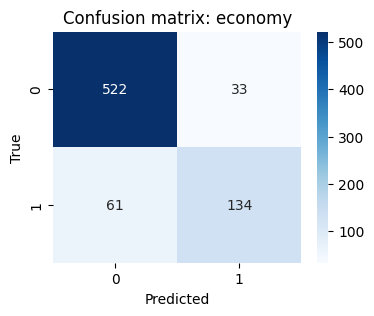

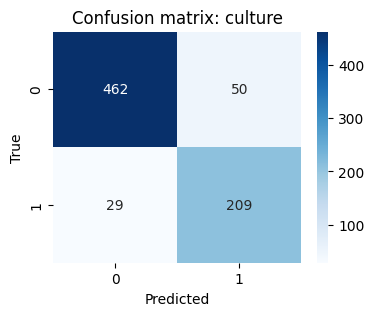

In [182]:
labels = ["politics", "economy", "culture"]

for i, name in enumerate(labels):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [183]:
import os
import torch
import joblib

save_dir = "model_checkpoint"
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), f"{save_dir}/model.pt")


tokenizer.save_pretrained(save_dir)

joblib.dump(thresholds, f"{save_dir}/thresholds.pkl")

['model_checkpoint/thresholds.pkl']

In [ ]:
# model.load_state_dict(torch.load("model_checkpoint/model.pt", map_location=device))
# model.to(device)
# model.eval()
# from transformers import AutoTokenizer
# import joblib

# tokenizer = AutoTokenizer.from_pretrained("model_checkpoint")
# thresholds = joblib.load("model_checkpoint/thresholds.pkl")

## 9. Деплой и мониторинг, A/B - 2 балла

Опишите, как вы будете выкатывать в модель в прод:
- как будет выглядеть пайплайн от момента, когда вам пришел текст и заголовок новости, до передачи вердиктов по категориям новости.
- как вы распределите железо для инференса: будет использоваться GPU или CPU (или какая-то комбинация), и как вы это обоснуете.
- как бы вы проводили A/B тест с учетом вашего ML и бизнес-целей? Что бы замеряли? Как бы делили на группы? Как измеряли бы значимость изменений?
- как бы вы настраивали мониторинг? Что бы отслеживали? Для чего бы вы это делали?

In [ ]:

# ---- Ваш код здесь ----
print("""
1. Пайплайн:
title + text → tokenizer → encoder (BERT) → 
3 бинарные головы → sigmoid → thresholds → итоговые классы (politics/economy/culture)

2. Железо:
GPU — для инференса модели (ускорение и батчи)
CPU — для предобработки, токенизации и fallback
→ гибрид для баланса скорости и стоимости

3. A/B тест:
делим пользователей на 2 группы (A — старая модель, B — новая)
сравниваем:
- ML: F1 (micro/macro)
- бизнес: CTR

Также у нас уже были расписаны до этого метрики. Их тоже можно использовать

- Оффлайн
  - Per-label Precision, Recall, F1
  - Micro / Macro average F1
  - Accuracy (что все классы в новости верны)
- Онлайн
  - Среднее время пользователей на сайте
  - Среднее количество прочитанных новостей по пользователям
  - Среднее CTR по рекламе

значимость — через bootstrap / t-test

4. Мониторинг:
- качество: распределение предсказаний
- data drift: изменение входных текстов
- поведение модели: confidence
- система: latency, GPU utilization, ошибки

""")
# ---- Конец кода ----

## 10. Итерации улучшения - 3 балла

Проанализируйте внимательно ваше решение, какие в нем есть проблемы и что можно улучшить. Придумайте (сами) максимально полный список того, что можно в модели сделать по-другому и улучшить, чтобы повысить качество модели.

**При желании** (это не повлияет на оценку), выберите одно из таких улучшений, внедрите, после чего выведите в одной ячейке метрики на тесте вашего прошлого и нового решений -- удалось ли улучшить результат?

In [32]:

# ---- Ваш код здесь ----
print("""
Возможные улучшения:

- Улучшение данных:
  - ручная разметка части данных (gold dataset)
  - фильтрация/очистка LLM-разметки
  - ускорение разметки. Сейчас где-то 9-10 часов на 5000 объектов.
  - data augmentation

- Улучшение модели:
  - более мощный encoder (ruBERT-large, XLM-R)
  - использовать mean pooling вместо CLS
  - multilabel head вместо независимых голов
  - учитывать зависимости между классами. Тип если взять одну голову вместо головы на каждый класс.

- Обучение:
  - class weights / focal loss для дисбаланса
  - более долгий fine-tuning
  - learning rate scheduling
  - заморозка/разморозка слоёв

- Работа с текстом:
  - использовать больше контекста (увеличить max_length)
  - разбивать длинные тексты на чанки

- Постобработка:
  - более точный подбор thresholds
  - калибровка вероятностей 

- Ансамбли:
  - несколько моделей → усреднение

""")
# ---- Конец кода ----


Возможные улучшения:

- Улучшение данных:
  - ручная разметка части данных (gold dataset)
  - фильтрация/очистка LLM-разметки
  - ускорение разметки. Сейчас где-то 9-10 часов на 5000 объектов.
  - data augmentation

- Улучшение модели:
  - более мощный encoder (ruBERT-large, XLM-R)
  - использовать mean pooling вместо CLS
  - multilabel head вместо независимых голов
  - учитывать зависимости между классами. Тип если взять одну голову вместо головы на каждый класс.

- Обучение:
  - class weights / focal loss для дисбаланса
  - более долгий fine-tuning
  - learning rate scheduling
  - заморозка/разморозка слоёв

- Работа с текстом:
  - использовать больше контекста (увеличить max_length)
  - разбивать длинные тексты на чанки

- Постобработка:
  - более точный подбор thresholds
  - калибровка вероятностей 

- Ансамбли:
  - несколько моделей → усреднение




## 11. Расширение категорий (10 баллов)

Как это часто бывает, к вам пришел бизнес и сказал: "мы передумали".

Всё тщательно обсудив на встрече, главный продакт-менеджер заявил, что новостное агентство нуждается в другом наборе категорий, а именно: нужно выделить новые категории, "технологии" и "спорт", а три старые в целом могут оставаться на месте (правда никто не знает, надолго ли).

Итого, **новый список:** `["политика","экономика","технологии","спорт","культура"]`

Реализуйте это изменение и выведите новые метрики по всем категориям (старым и новым), но перед этим посмотрите на архитектуру своего решения и ответьте на вопрос -- насколько легко и удобно будет а) добавлять новые категории в вашем ML б) перекатывать сервис?

In [17]:
import transformers
import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, BitsAndBytesConfig
import json
import re
import pandas as pd

In [5]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.5.1+cu121
12.1
True
CUDA available: True
Device count: 1
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


In [64]:
# ---- Ваш код здесь ----
print("""
    Загружаем выбранную LLM
    В некоторых случаях может понадобиться !pip install -U accelerate bitsandbytes transformers
""")


    Загружаем выбранную LLM
    В некоторых случаях может понадобиться !pip install -U accelerate bitsandbytes transformers



In [ ]:
MODEL_NAME = "IlyaGusev/saiga_yandexgpt_8b"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True
)

In [7]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(129024, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear8bitLt(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear8bitLt(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear8bitLt(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear8bitLt(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-06)
      )
    )
    (

In [8]:
generation_config = GenerationConfig.from_pretrained(MODEL_NAME)
print(generation_config)

GenerationConfig {
  "bos_token_id": 1,
  "do_sample": true,
  "eos_token_id": 128009,
  "max_length": 1024000,
  "max_new_tokens": 2048,
  "pad_token_id": 0,
  "repetition_penalty": 1.1,
  "temperature": 0.6,
  "top_p": 0.95
}



In [9]:
generation_config.do_sample = False
generation_config.max_new_tokens = 256
generation_config.use_cache = True
generation_config.max_length = None

In [10]:
generation_config

GenerationConfig {
  "bos_token_id": 1,
  "do_sample": false,
  "eos_token_id": 128009,
  "max_new_tokens": 256,
  "pad_token_id": 0,
  "repetition_penalty": 1.1,
  "temperature": 0.6,
  "top_p": 0.95,
  "use_cache": true
}

In [11]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [ ]:

# ---- Конец кода ----

In [19]:
# Промпт

def prompt_template(text: str):
    return f"""Ты — эксперт по классификации новостей.
    Твоя задача: определить, к каким категориям относится новость.
    
    Категории:
    - technologies — технологии, IT, искусственный интеллект, гаджеты, интернет, стартапы, программирование, наука
    - sport — спорт, соревнования, матчи, команды, игроки, турниры, результаты
    
    Важно:
    - Можно выбрать несколько категорий одновременно
    - Можно выбрать ни одной (если новость не относится)
    - Отвечай ТОЛЬКО в заданном формате
    
    Формат ответа:
    {{
        "generation": "your short reasoning",
        "technologies": 0 или 1,
        "sport": 0 или 1
    }}
    
    Новость:
    {text}
"""
# ---- Конец кода ----

In [20]:
len_prompt = len(prompt_template(''))

In [21]:
len_prompt

634

In [22]:
 # Функция разметки

# @torch.no_grad() # можно включить декоратор
def annotate(text: str, max_length:int=2560) -> dict:
    """
    Формат markup следующий
        markup = {
        'politics': 0/1,
        'economy': 0/1,
        'culture': 0/1,
        'corrupted': 0/1, # сломалось ли что-то при получении разметки
        'generation': llm_generation # чтобы можно было раздебажить закоррапченные разметки
    }
    """
    try:
        # вставляем текст в шаблон, обрезаем на всякий чтоб не падало по памяти лишний раз
        # prompt_input = prompt_template.format(text=text[:1500]) # обрезаем слишком длинные новости


        # может понадобиться, может нет -- зависит от выбранной вами модели
        # prompt = tokenizer.apply_chat_template([{
        #     "role": "user",
        #     "content": prompt_input
        # }], tokenize=False, add_generation_prompt=True)

        # markup = {}
        # with torch.no_grad():
        #     # inference tokenizer, model ...

        #     del ... # удаляем ненужные переменные
        #     torch.cuda.empty_cache()

        #     return markup

        # ---- Ваш код здесь ----
        with torch.inference_mode():
            prompt_input = prompt_template(text[:1500]) # обрезаем слишком длинные новости
    
            prompt = tokenizer.apply_chat_template([{
                "role": "user",
                "content": prompt_input
            }], tokenize=False, add_generation_prompt=True)
            
            data = tokenizer(prompt, return_tensors="pt", add_special_tokens=False)
            # data = {k: v.to(model.device) for k, v in data.items()}
            # data.pop("token_type_ids", None)
            data.to(model.device)
            output_ids = model.generate(**data, generation_config=generation_config)[0]
            output_ids = output_ids[len(data["input_ids"][0]):]
            output = tokenizer.decode(output_ids, skip_special_tokens=True).strip()
            
            del data, output_ids, prompt, prompt_input
    
            gc.collect()
            
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()
    
        try: 
            start = output.find('{')
            end = output.find('}') + 1
            markup = json.loads(output[start:end])
            markup['corrupted'] = 0
        except:
            markup = {
                'technologies': 0, 'sport': 0,
                'corrupted': 1,
                'generation': output
            }

        return markup
    # ---- Конец кода ----

    except torch.cuda.OutOfMemoryError:
        print("CUDA OOM. Освобождаем память...")
        torch.cuda.empty_cache()
        return {
            'technologies': 0, 'sport': 0,
            'corrupted': 1,
            'generation': 'OOM_ERROR'
        }

In [36]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [18]:
data = pd.read_csv('../../files/razmetka_all.csv')
data

,Unnamed: 0,source,title,text,publication_date,generation,politics,economy,culture,corrupted
0,0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00,История трудового подвига Алексея Стаханова в ...,1,1,1,0
1,1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00,Спортсменка Алина Загитова решила расширить св...,0,0,1,0
2,2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00,"Статья посвящена здоровью и питанию, но содерж...",0,0,0,0
3,3,lenta.ru,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,2020-08-30T00:04:00+03:00,Влияние телевизионного шоу '16 and Pregnant' н...,0,0,1,0
4,4,lenta.ru,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,2020-08-31T18:27:00+03:00,Эта новость касается личной жизни известного а...,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
4995,4995,lenta.ru,Выступавший в НХЛ игрок назвал плюсы жизни в К...,Российский хоккеист московского ЦСКА Никола...,2020-04-17T23:46:00+03:00,Сравнение жизни в разных странах через призму ...,0,0,1,0
4996,4996,lenta.ru,Песков объяснил причину переноса сроков подачи...,Пресс-секретарь президента России Дмитрий Пес...,2020-04-17T23:23:00+03:00,Перенос сроков подачи деклараций о доходах чин...,1,0,0,0
4997,4997,lenta.ru,Лукашенко раскритиковал российские тесты на ко...,Президент Белоруссии Александр Лукашенко рас...,2020-04-17T22:51:00+03:00,Критика российских тестов и советы населению о...,1,1,0,0
4998,4998,lenta.ru,В Петербурге медики массово заразились коронав...,В Боткинскую больницу в Санкт-Петербурге госпи...,2020-04-17T22:17:00+03:00,Эта новость касается распространения COVID-19 ...,1,0,0,0


In [23]:
output = annotate(data.loc[0]['title'] + '. ' + data.loc[0]['text'])
output

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=256) and `max_length`(=1024000) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
C:\ProgramData\anaconda3\envs\llm\Lib\site-packages\bitsandbytes\autograd\_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


{'generation': 'Статья рассказывает об историческом событии - установлении рекорда Алексеем Стахановым в 1935 году, что стало символом трудового подвига в СССР. Также затрагивается тема влияния этого события на развитие технологий и методов работы в угольной промышленности.',
 'technologies': 1,
 'sport': 0,
 'corrupted': 0}

In [24]:
data.columns

Index(['Unnamed: 0', 'source', 'title', 'text', 'publication_date',
       'generation', 'politics', 'economy', 'culture', 'corrupted'],
      dtype='str')

In [25]:
from tqdm import tqdm

In [28]:
n_max = 9999999

In [29]:
data[:n_max]

,Unnamed: 0,source,title,text,publication_date,generation,politics,economy,culture,corrupted
0,0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00,История трудового подвига Алексея Стаханова в ...,1,1,1,0
1,1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00,Спортсменка Алина Загитова решила расширить св...,0,0,1,0
2,2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00,"Статья посвящена здоровью и питанию, но содерж...",0,0,0,0
3,3,lenta.ru,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,2020-08-30T00:04:00+03:00,Влияние телевизионного шоу '16 and Pregnant' н...,0,0,1,0
4,4,lenta.ru,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,2020-08-31T18:27:00+03:00,Эта новость касается личной жизни известного а...,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
4995,4995,lenta.ru,Выступавший в НХЛ игрок назвал плюсы жизни в К...,Российский хоккеист московского ЦСКА Никола...,2020-04-17T23:46:00+03:00,Сравнение жизни в разных странах через призму ...,0,0,1,0
4996,4996,lenta.ru,Песков объяснил причину переноса сроков подачи...,Пресс-секретарь президента России Дмитрий Пес...,2020-04-17T23:23:00+03:00,Перенос сроков подачи деклараций о доходах чин...,1,0,0,0
4997,4997,lenta.ru,Лукашенко раскритиковал российские тесты на ко...,Президент Белоруссии Александр Лукашенко рас...,2020-04-17T22:51:00+03:00,Критика российских тестов и советы населению о...,1,1,0,0
4998,4998,lenta.ru,В Петербурге медики массово заразились коронав...,В Боткинскую больницу в Санкт-Петербурге госпи...,2020-04-17T22:17:00+03:00,Эта новость касается распространения COVID-19 ...,1,0,0,0


In [30]:
! dir

 Volume in drive C is Windows 11
 Volume Serial Number is 8080-D278

 Directory of C:\Users\bigdata\Documents\education\deepschool_homework\homework_1

04/18/2026  04:26 PM    <DIR>          .
04/15/2026  06:36 PM    <DIR>          ..
04/15/2026  06:39 PM    <DIR>          .ipynb_checkpoints
04/18/2026  04:26 PM           352,970 LLMpro_hw1_Abdullin_RI.ipynb
04/18/2026  12:45 AM    <DIR>          model_checkpoint
               1 File(s)        352,970 bytes
               4 Dir(s)  211,911,856,128 bytes free


In [37]:
new_rows = list()
save_n = 500
i = 0
part = 0
n_max = 9999999

for _, row in tqdm(data[:n_max].iterrows(), total=data[:n_max].shape[0]):
    output = annotate(row['title'] + '. ' + row['text'])
    new_row = {'source': row['source'], 
               'title': row['title'],
               'text' : row['text'], 
               'publication_date' : row['publication_date']}

    new_row.update(output)
    new_rows.append(new_row)
    i += 1
    
    if i == save_n:
        pd.DataFrame(new_rows).to_csv(f'../../files/razmetka_2/razmetka_part_{part}.csv', index=None)
        part += 1
        i = 0
        del new_rows

        gc.collect()
        new_rows = list()

if len(new_rows) > 0:
    pd.DataFrame(new_rows).to_csv(f'../../files/razmetka_2/razmetka_part_{part}.csv', index=None)

100%|███████████████████████████████████████████████████████████████████████████| 5000/5000 [12:47:04<00:00,  9.20s/it]


## Dataset и train_test_split

Забыл зафиксировать random_state. Я бы проделал все занаво и оставил одинаковый тест. 

In [40]:
# ---- Ваш код здесь ----
print("EDA и разделение на трейн-тест")

import pandas as pd
import glob
import os
import gc

EDA и разделение на трейн-тест


In [41]:
path = '../../files/razmetka_2/'

In [42]:
files = glob.glob(os.path.join(path, "razmetka_part_*.csv"))

In [43]:
files

['../../files/razmetka_2\\razmetka_part_0.csv',
 '../../files/razmetka_2\\razmetka_part_1.csv',
 '../../files/razmetka_2\\razmetka_part_2.csv',
 '../../files/razmetka_2\\razmetka_part_3.csv',
 '../../files/razmetka_2\\razmetka_part_4.csv',
 '../../files/razmetka_2\\razmetka_part_5.csv',
 '../../files/razmetka_2\\razmetka_part_6.csv',
 '../../files/razmetka_2\\razmetka_part_7.csv',
 '../../files/razmetka_2\\razmetka_part_8.csv',
 '../../files/razmetka_2\\razmetka_part_9.csv']

In [41]:
for f in files:
    try:
        t = pd.read_csv(f)
        del t
        gc.collect()
    except:
        print(f)

../../files/razmetka\razmetka_part_200.csv


In [44]:
df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

In [46]:
df.columns

Index(['source', 'title', 'text', 'publication_date', 'generation',
       'technologies', 'sport', 'corrupted', 'health', 'crime', 'safety',
       'animals', 'economics', 'politics', 'personal stories', 'society',
       'science', 'human_rights', 'religion'],
      dtype='str')

In [48]:
df[['source', 'title', 'text', 'publication_date', 'generation', 'technologies', 'sport']]

,source,title,text,publication_date,generation,technologies,sport
0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00,Статья рассказывает об историческом событии - ...,1,0.0
1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00,Новость касается спортивной деятельности Алины...,0,1.0
2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00,Статья посвящена вопросам здорового питания и ...,0,0.0
3,lenta.ru,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,2020-08-30T00:04:00+03:00,Статья затрагивает тему влияния телевизионного...,0,0.0
4,lenta.ru,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,2020-08-31T18:27:00+03:00,Эта новость касается личной жизни известного а...,0,0.0
...,...,...,...,...,...,...,...
4995,lenta.ru,Выступавший в НХЛ игрок назвал плюсы жизни в К...,Российский хоккеист московского ЦСКА Никола...,2020-04-17T23:46:00+03:00,Эта новость касается спорта и личных впечатлен...,0,1.0
4996,lenta.ru,Песков объяснил причину переноса сроков подачи...,Пресс-секретарь президента России Дмитрий Пес...,2020-04-17T23:23:00+03:00,Новость касается продления сроков подачи декла...,0,0.0
4997,lenta.ru,Лукашенко раскритиковал российские тесты на ко...,Президент Белоруссии Александр Лукашенко рас...,2020-04-17T22:51:00+03:00,"Эта новость касается политики и медицины, но с...",1,0.0
4998,lenta.ru,В Петербурге медики массово заразились коронав...,В Боткинскую больницу в Санкт-Петербурге госпи...,2020-04-17T22:17:00+03:00,Эта новость касается пандемии COVID-19 и её вл...,0,0.0


In [49]:
df[['source', 'title', 'text', 'publication_date', 'generation', 'technologies', 'sport', 'corrupted']].to_csv('../../files/razmetka_all_2.csv')

In [55]:
data = pd.read_csv('../../files/razmetka_all.csv', index_col=0)
data

,source,title,text,publication_date,generation,politics,economy,culture,corrupted
0,lenta.ru,Синий богатырь,В 1930-е годы Советский Союз охватила лихорадк...,2020-08-30T00:01:00+03:00,История трудового подвига Алексея Стаханова в ...,1,1,1,0
1,lenta.ru,Загитова согласилась вести «Ледниковый период»,Олимпийская чемпионка по фигурному катанию Ал...,2020-08-31T20:04:00+03:00,Спортсменка Алина Загитова решила расширить св...,0,0,1,0
2,lenta.ru,Объяснена опасность однообразного питания,Российский врач-диетолог Римма Мойсенко объясн...,2020-08-31T20:07:00+03:00,"Статья посвящена здоровью и питанию, но содерж...",0,0,0,0
3,lenta.ru,«Предохраняться? А зачем?»,В 2019 году телеканал «Ю» запустил адаптацию з...,2020-08-30T00:04:00+03:00,Влияние телевизионного шоу '16 and Pregnant' н...,0,0,1,0
4,lenta.ru,Ефремов систематически употреблял наркотики,Актер Михаил Ефремов систематически употребл...,2020-08-31T18:27:00+03:00,Эта новость касается личной жизни известного а...,0,0,1,0
...,...,...,...,...,...,...,...,...,...
4995,lenta.ru,Выступавший в НХЛ игрок назвал плюсы жизни в К...,Российский хоккеист московского ЦСКА Никола...,2020-04-17T23:46:00+03:00,Сравнение жизни в разных странах через призму ...,0,0,1,0
4996,lenta.ru,Песков объяснил причину переноса сроков подачи...,Пресс-секретарь президента России Дмитрий Пес...,2020-04-17T23:23:00+03:00,Перенос сроков подачи деклараций о доходах чин...,1,0,0,0
4997,lenta.ru,Лукашенко раскритиковал российские тесты на ко...,Президент Белоруссии Александр Лукашенко рас...,2020-04-17T22:51:00+03:00,Критика российских тестов и советы населению о...,1,1,0,0
4998,lenta.ru,В Петербурге медики массово заразились коронав...,В Боткинскую больницу в Санкт-Петербурге госпи...,2020-04-17T22:17:00+03:00,Эта новость касается распространения COVID-19 ...,1,0,0,0


In [56]:
data_2 = pd.read_csv('../../files/razmetka_all_2.csv', index_col=0)

In [58]:
data_2.rename(columns={'generation': 'generation_2', 'corrupted': 'corrupted_2'}, inplace=True)

In [61]:
new_data = data.merge(data_2, on=['source', 'title', 'text', 'publication_date'])

In [63]:
data = new_data

In [72]:
print(data[data['corrupted_2'] == 1]['generation_2'][1709])

```json
{
    "generation": "Эта новость касается политической ситуации в Беларуси, включая задержание соратницы оппозиционного кандидата и бегство других кандидатов от преследования властей. Однако, учитывая контекст новости, можно выделить следующие категории:
    - technologies: 0 (так как новость больше связана с политикой и обществом)",
    "technologies": 0,
    "sport": 0
}
```


In [77]:
data.loc[data['corrupted_2'] == 1, ['technologies', 'sport', 'corrupted_2']] = 0

In [79]:
data['corrupted_2'].value_counts()

corrupted_2
0    5000
Name: count, dtype: int64

In [80]:
data.technologies.isna().sum()

np.int64(0)

In [81]:
data.sport.isna().sum()

np.int64(1)

In [82]:
data[data.sport.isna()]

,source,title,text,publication_date,generation,politics,economy,culture,corrupted,generation_2,technologies,sport,corrupted_2
390,lenta.ru,В ВОЗ рассказали о темпах эпидемии коронавирус...,Эпидемия коронавируса в России только набирает...,2020-04-03T18:56:00+03:00,Эпидемия коронавируса в России рассматривается...,1,0,0,0,Эта новость касается эпидемиологической ситуац...,0,NaN,0


In [83]:
data.loc[data.sport.isna(), ['sport']] = 0

In [84]:
data.sport.isna().sum()

np.int64(0)

In [85]:
data.groupby(['politics', 'economy', 'culture', 'technologies', 'sport'])['source'].count().to_frame() / data.shape[0] * 100

source
politics economy culture technologies sport        
0        0       0       0            0.0      4.06
                                      1.0      1.12
                         1            0.0      2.48
                                      1.0      0.62
                 1       0            0.0      7.12
                                      1.0      4.72
                         1            0.0      3.66
                                      1.0      2.48
         1       0       0            0.0      1.80
                                      1.0      0.22
                         1            0.0      1.78
                                      1.0      0.20
                 1       0            0.0      0.62
                                      1.0      0.42
                         1            0.0      0.52
                                      1.0      0.26
1        0       0       0            0.0     23.10
                                      1.0      1.50
                         1            0.0     12.04
                                      1.0      1.70
                 1       0            0.0      5.52
                                      1.0      1.12
                         1            0.0      1.58
                                      1.0      0.72
         1       0       0            0.0     10.76
                                      1.0      0.54
                         1            0.0      6.90
                                      1.0      0.70
                 1       0            0.0      0.78
                                      1.0      0.08
                         1            0.0      0.68
                                      1.0      0.20

In [163]:
for c in ['politics', 'economy', 'culture', 'technologies', 'sport']:
    display(data[data[c] == 1].shape[0]) 

3396

1323

1524

1826

830

In [86]:
for c in ['politics', 'economy', 'culture', 'technologies', 'sport']:
    display(data[c].value_counts(normalize=True))

politics
1    0.6792
0    0.3208
Name: proportion, dtype: float64

economy
0    0.7354
1    0.2646
Name: proportion, dtype: float64

culture
0    0.6952
1    0.3048
Name: proportion, dtype: float64

technologies
0    0.6348
1    0.3652
Name: proportion, dtype: float64

sport
0.0    0.834
1.0    0.166
Name: proportion, dtype: float64

In [147]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(data, test_size=0.15)

train_df, val_df = train_test_split(train_df, test_size=0.10)

In [148]:
(train_df.shape[0] / data.shape[0],
 val_df.shape[0] / data.shape[0],
test_df.shape[0] / data.shape[0])

(0.765, 0.085, 0.15)

In [149]:
for c in ['politics', 'economy', 'culture', 'technologies', 'sport']:
    display(train_df[c].value_counts(normalize=True))

politics
1    0.675294
0    0.324706
Name: proportion, dtype: float64

economy
0    0.744314
1    0.255686
Name: proportion, dtype: float64

culture
0    0.693072
1    0.306928
Name: proportion, dtype: float64

technologies
0    0.635033
1    0.364967
Name: proportion, dtype: float64

sport
0.0    0.830588
1.0    0.169412
Name: proportion, dtype: float64

In [150]:
for c in ['politics', 'economy', 'culture', 'technologies', 'sport']:
    display(test_df[c].value_counts(normalize=True))

politics
1    0.7
0    0.3
Name: proportion, dtype: float64

economy
0    0.709333
1    0.290667
Name: proportion, dtype: float64

culture
0    0.698667
1    0.301333
Name: proportion, dtype: float64

technologies
0    0.638667
1    0.361333
Name: proportion, dtype: float64

sport
0.0    0.856
1.0    0.144
Name: proportion, dtype: float64

## Переобучение, дообучение

В целом можно было бы дообучить, но я тест забыл сохранить одинаковый... При текущем разделении в тест могут попасть объекты из предыдущего трейна, поэтому просто переобучу все, чтобы нормально смотреть качество. Также я бы делал все это в отдельных блокнотах, потому что я бы точно это все в разное время перезапускал, также тут уже тяжело скроллить...


In [151]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
from tqdm import tqdm
import os
import joblib


# ---- Ваш код здесь ----
print("Пишем классы, обучаем")
# ---- Конец кода ----

Пишем классы, обучаем


In [152]:
class NewsDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=512):
        self.texts = (df["title"] + " " + df["text"]).tolist()
        self.labels = df[["politics", "economy", "culture", "technologies", "sport"]].values.astype(float)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)

        return item

In [153]:
class MultiHeadClassifier(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.head_politics = nn.Linear(hidden_size, 1)
        self.head_economy = nn.Linear(hidden_size, 1)
        self.head_culture = nn.Linear(hidden_size, 1)
        self.head_technologies = nn.Linear(hidden_size, 1)
        self.head_sport = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = outputs.last_hidden_state[:, 0]  # CLS токен

        p = self.head_politics(cls)
        e = self.head_economy(cls)
        c = self.head_culture(cls)
        t = self.head_technologies(cls)
        s = self.head_sport(cls)

        logits = torch.cat([p, e, c, t, s], dim=1)

        return logits


In [195]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)

train_dataset = NewsDataset(train_df, tokenizer)
val_dataset = NewsDataset(val_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

model = MultiHeadClassifier(model_name).to(device)
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

In [196]:
print(type(model))

<class '__main__.MultiHeadClassifier'>


In [197]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader):
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)

            loss = criterion(logits, labels)

            total_loss += loss.item()

            probs = torch.sigmoid(logits)

            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    return total_loss / len(loader), np.vstack(all_preds), np.vstack(all_labels)

In [198]:
print(type(model))

<class '__main__.MultiHeadClassifier'>


In [199]:
EPOCHS = 3

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}")

    train_loss = train_epoch(model, train_loader)
    val_loss, preds, labels = eval_epoch(model, val_loader)

    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss: {val_loss:.4f}")


Epoch 1


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 19.75it/s]


Train loss: 0.5328
Val loss: 0.4344

Epoch 2


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 18.20it/s]


Train loss: 0.3839
Val loss: 0.3457

Epoch 3


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 19.77it/s]

Train loss: 0.3289
Val loss: 0.3271


In [200]:
preds

array([[0.75222576, 0.9669585 , 0.01500503, 0.37296176, 0.03714489],
       [0.0461023 , 0.06921284, 0.55503005, 0.32966185, 0.14109486],
       [0.557297  , 0.66574943, 0.06458822, 0.8471923 , 0.11765004],
       ...,
       [0.9950448 , 0.17085573, 0.02655867, 0.16380958, 0.03106847],
       [0.15736215, 0.03123763, 0.6870481 , 0.32201645, 0.9520992 ],
       [0.44699222, 0.05017958, 0.6274793 , 0.23255122, 0.09014171]],
      shape=(425, 5), dtype=float32)

In [201]:
from sklearn.metrics import roc_auc_score

In [202]:
y_true = val_df[["politics", "economy", "culture", "technologies", "sport"]].values
y_score = preds

In [203]:
results = {}

for i, name in enumerate(["politics", "economy", "culture", "technologies", "sport"]):
    results[name] = roc_auc_score(y_true[:, i], y_score[:, i])

pd.Series(results)

politics        0.951566
economy         0.911695
culture         0.952685
technologies    0.769731
sport           0.877647
dtype: float64

In [204]:
from sklearn.metrics import f1_score

def find_best_thresholds(preds, labels):
    thresholds = []

    for i in range(labels.shape[1]):
        best_f1 = 0
        best_t = 0.5

        for t in np.linspace(0.1, 0.9, 17):
            pred_bin = (preds[:, i] > t).astype(int)
            f1 = f1_score(labels[:, i], pred_bin)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds.append(best_t)

    return thresholds

In [205]:
thresholds = find_best_thresholds(y_score, y_true)

In [206]:
thresholds

[np.float64(0.4),
 np.float64(0.45000000000000007),
 np.float64(0.45000000000000007),
 np.float64(0.30000000000000004),
 np.float64(0.35)]

In [207]:
def get_scores(model, loader, device):
    model.eval()
    all_scores = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits)

            all_scores.append(probs.cpu().numpy())

    return np.vstack(all_scores)

In [208]:
def predict(model, loader, thresholds):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(loader):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            logits = model(input_ids, attention_mask)
            probs = torch.sigmoid(logits)

            all_preds.append(probs.cpu().numpy())

    probs = np.vstack(all_preds)

    preds = (probs > thresholds).astype(int)

    return preds

In [209]:
test_dataset = NewsDataset(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [210]:
val_preds = predict(model, val_loader, thresholds)

100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 19.66it/s]


In [211]:
val_preds

array([[1, 1, 0, 1, 0],
       [0, 0, 1, 1, 0],
       [1, 1, 0, 1, 0],
       ...,
       [1, 0, 0, 0, 0],
       [0, 0, 1, 1, 1],
       [1, 0, 1, 0, 0]], shape=(425, 5))

In [212]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import numpy as np

In [213]:
y_true = val_df[["politics", "economy", "culture", "technologies", "sport"]].values
y_pred = val_preds  

labels = ["politics", "economy", "culture", "technologies", "sport"]

for i, name in enumerate(labels):
    precision = precision_score(y_true[:, i], y_pred[:, i])
    recall = recall_score(y_true[:, i], y_pred[:, i])
    f1 = f1_score(y_true[:, i], y_pred[:, i])

    print(f"{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")

politics:
  Precision: 0.9113
  Recall:    0.9271
  F1:        0.9191
economy:
  Precision: 0.8704
  Recall:    0.7402
  F1:        0.8000
culture:
  Precision: 0.8448
  Recall:    0.7903
  F1:        0.8167
technologies:
  Precision: 0.5459
  Recall:    0.7484
  F1:        0.6313
sport:
  Precision: 0.9600
  Recall:    0.6486
  F1:        0.7742


In [214]:
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

Micro F1: 0.8041104688503532
Macro F1: 0.7882529882391844


In [215]:
strict_accuracy = accuracy_score(y_true, y_pred)

print("Strict (subset) accuracy:", strict_accuracy)

Strict (subset) accuracy: 0.44


In [216]:
test_preds = predict(model, test_loader, thresholds)

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:01<00:00, 19.33it/s]


In [217]:
y_true = test_df[["politics", "economy", "culture", "technologies", "sport"]].values
y_pred = test_preds  # уже после thresholding

labels = ["politics", "economy", "culture", "technologies", "sport"]

for i, name in enumerate(labels):
    precision = precision_score(y_true[:, i], y_pred[:, i])
    recall = recall_score(y_true[:, i], y_pred[:, i])
    f1 = f1_score(y_true[:, i], y_pred[:, i])

    print(f"{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")

politics:
  Precision: 0.8998
  Recall:    0.9238
  F1:        0.9117
economy:
  Precision: 0.8650
  Recall:    0.6468
  F1:        0.7402
culture:
  Precision: 0.8426
  Recall:    0.8053
  F1:        0.8235
technologies:
  Precision: 0.5310
  Recall:    0.6642
  F1:        0.5902
sport:
  Precision: 0.7952
  Recall:    0.6111
  F1:        0.6911


In [218]:
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

Micro F1: 0.7842261904761905
Macro F1: 0.7513208876568064


In [219]:
strict_accuracy = accuracy_score(y_true, y_pred)

print("Strict (subset) accuracy:", strict_accuracy)

Strict (subset) accuracy: 0.42


## 8. Оценка и интерпретация - 5 баллов

Постройте и посчитайте следующие вещи на тесте для каждой категории:
- Графики: roc-кривую, распределение вероятностей для класса 1 и 0 (на одном графике), confusion matrix
- Метрики: precision, recall, f1 при оптимально подобранном пороге, roc auc

In [220]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

In [221]:
y_true = test_df[["politics", "economy", "culture", "technologies", "sport"]].values
y_pred = test_preds  

labels = ["politics", "economy", "culture", "technologies", "sport"]

for i, name in enumerate(labels):
    precision = precision_score(y_true[:, i], y_pred[:, i])
    recall = recall_score(y_true[:, i], y_pred[:, i])
    f1 = f1_score(y_true[:, i], y_pred[:, i])

    print(f"{name}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1:        {f1:.4f}")

politics:
  Precision: 0.8998
  Recall:    0.9238
  F1:        0.9117
economy:
  Precision: 0.8650
  Recall:    0.6468
  F1:        0.7402
culture:
  Precision: 0.8426
  Recall:    0.8053
  F1:        0.8235
technologies:
  Precision: 0.5310
  Recall:    0.6642
  F1:        0.5902
sport:
  Precision: 0.7952
  Recall:    0.6111
  F1:        0.6911


In [222]:
micro_f1 = f1_score(y_true, y_pred, average="micro")
macro_f1 = f1_score(y_true, y_pred, average="macro")

print("Micro F1:", micro_f1)
print("Macro F1:", macro_f1)

Micro F1: 0.7842261904761905
Macro F1: 0.7513208876568064


Accuracy, что новость целиком совпала

In [223]:
strict_accuracy = accuracy_score(y_true, y_pred)

print("Strict (subset) accuracy:", strict_accuracy)

Strict (subset) accuracy: 0.42


In [224]:
y_true

array([[0., 0., 1., 0., 0.],
       [1., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 1., 1., 1., 0.],
       [0., 0., 0., 0., 0.]], shape=(750, 5))

In [225]:
y_score = get_scores(model, test_loader, device)

100%|██████████████████████████████████████████████████████████████████████████████████| 24/24 [00:01<00:00, 19.19it/s]


In [226]:
y_score

array([[0.1502191 , 0.08214316, 0.9306895 , 0.29711428, 0.44344518],
       [0.2840703 , 0.00933145, 0.6286003 , 0.23040289, 0.33678156],
       [0.99376714, 0.17955661, 0.01889917, 0.25508744, 0.05541835],
       ...,
       [0.9713885 , 0.05480513, 0.02678377, 0.11307672, 0.11208635],
       [0.9021146 , 0.8070767 , 0.33333886, 0.5025044 , 0.02334613],
       [0.30486473, 0.2679438 , 0.06005269, 0.4228174 , 0.05439597]],
      shape=(750, 5), dtype=float32)

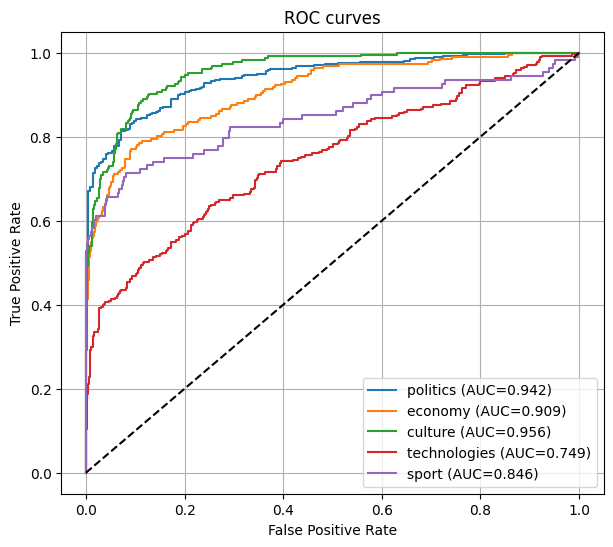

In [227]:
labels = ["politics", "economy", "culture", "technologies", "sport"]

plt.figure(figsize=(7, 6))

for i, name in enumerate(labels):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves")
plt.legend()
plt.grid()
plt.show()

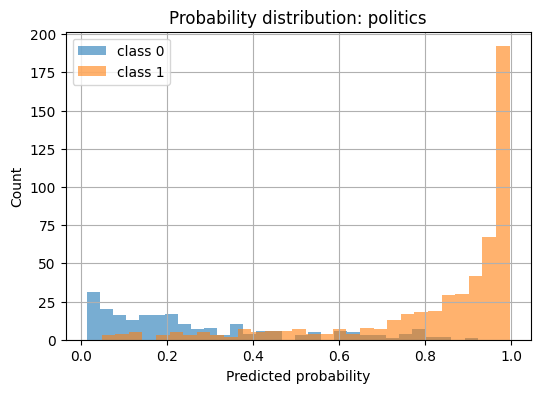

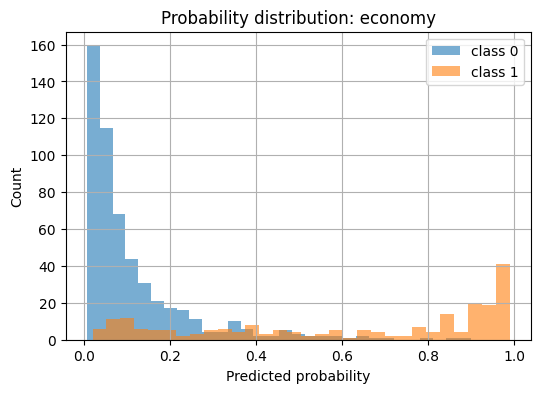

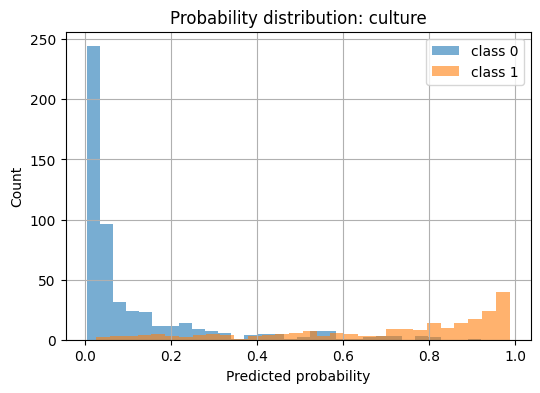

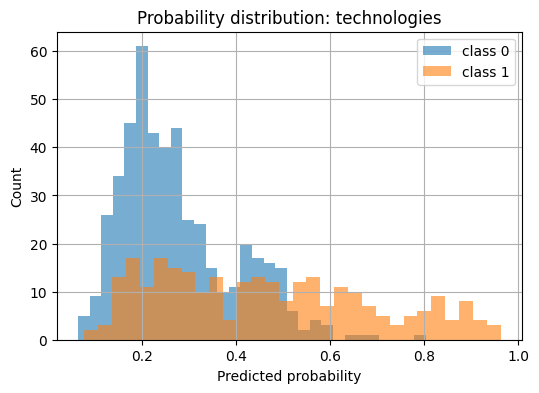

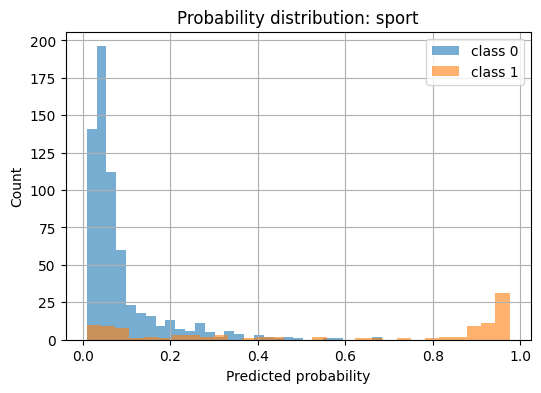

In [228]:
labels = ["politics", "economy", "culture", "technologies", "sport"]

for i, name in enumerate(labels):
    plt.figure(figsize=(6, 4))

    probs_pos = y_score[y_true[:, i] == 1, i]
    probs_neg = y_score[y_true[:, i] == 0, i]

    plt.hist(probs_neg, bins=30, alpha=0.6, label="class 0")
    plt.hist(probs_pos, bins=30, alpha=0.6, label="class 1")

    plt.title(f"Probability distribution: {name}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.legend()
    plt.grid()
    plt.show()

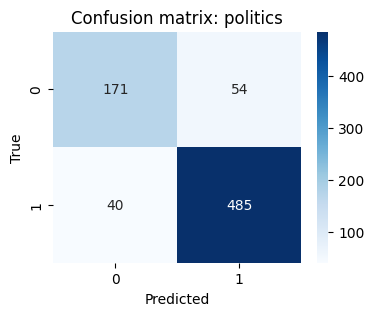

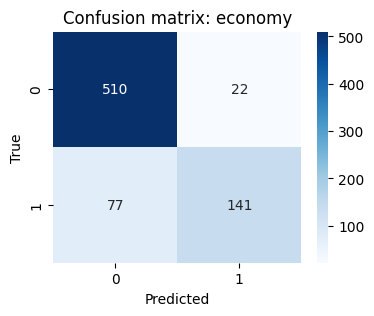

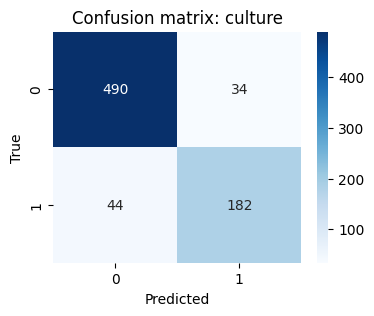

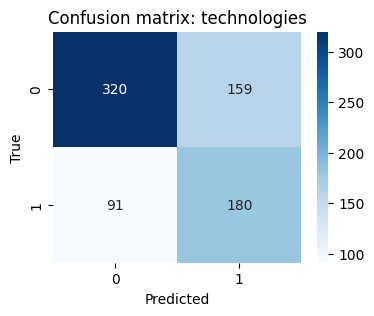

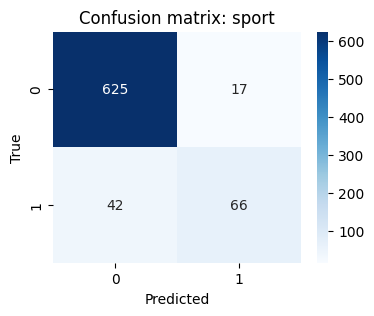

In [229]:
labels = ["politics", "economy", "culture", "technologies", "sport"]

for i, name in enumerate(labels):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i])

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion matrix: {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

In [230]:
import os
import torch
import joblib

save_dir = "model_checkpoint_2"
os.makedirs(save_dir, exist_ok=True)

torch.save(model.state_dict(), f"{save_dir}/model.pt")


tokenizer.save_pretrained(save_dir)

joblib.dump(thresholds, f"{save_dir}/thresholds.pkl")

['model_checkpoint_2/thresholds.pkl']

Видим, что класс технологии и культура имеют качество похуже чем предыдущие. Также заметил, что пороги других классов тоже немного изменились. ROC AUC примерно такой же по классам, но вероятности сместились левее как будто. Особенно класс технологии по распределению вероятностей как-то перемешан сильно по сравнению с другими. Как вы думаете, что я сделал не так?

In [ ]:

# ---- Конец кода ----